## Preprocess ##

Replace:
- '/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/' to '/media/osero/SamsungSSD/skeleton_openpose/'
- 'left_lunate_bone' to 'lunate_bone'

In [36]:
import cv2 
from matplotlib import pyplot as plt
from PIL import Image
import pickle
import shutil
import os
import glob
import csv
def calculate_min(data, hand_type, frame_number):
    x_min = 1920
    y_min = 1080
    for finger_key, finger_value in data[hand_type].items():
        cx = finger_value[frame_number][0]
        cy = finger_value[frame_number][1]
        if cx < x_min:
            x_min = cx
        if cy < y_min:
            y_min = cy
    return x_min, y_min

def create_csv_from_pose(csv_data, csv_header, class_number, hand_type):
    pose_folder_path = '/media/osero/SamsungSSD/skeleton_openpose/'+ str(class_number).zfill(4)
    pose_files = [os.path.basename(file) for file in glob.glob(os.path.join(pose_folder_path, '*')) if os.path.isfile(file)]

    for file_path in pose_files:
        # Open the video file
        user_name = os.path.splitext(file_path)[0]
        pose_pickle_path = os.path.join(pose_folder_path, file_path)
        file = open(pose_pickle_path, 'rb')
        data = pickle.load(file)
        frame_count = data[hand_type]['lunate_bone'].shape[0]

        if len(csv_header) == 3:
            for pose_key in data[hand_type].keys():
                csv_header.append(pose_key + '_x')
                csv_header.append(pose_key + '_y')
                csv_header.append(pose_key + '_z')

        for frame_number in range(0, frame_count):
            x_min, y_min = calculate_min(data, hand_type, frame_number)
            csv_row_data = []
            csv_row_data.append(class_number)
            csv_row_data.append(user_name)
            csv_row_data.append(frame_number)
            for finger_key, finger_value in data[hand_type].items():
                csv_row_data.append(finger_value[frame_number][0] - x_min)
                csv_row_data.append(finger_value[frame_number][1] - y_min)
                csv_row_data.append(finger_value[frame_number][2])
            csv_data.append(csv_row_data)


In [37]:
csv_header = ['ClassNumber', 'User', 'Frame']
csv_data = []
csv_data.append(csv_header)

for class_number in range(1, 744):
    create_csv_from_pose(csv_data, csv_header, class_number, 'hand_left')

with open('/media/osero/SamsungSSD/output.csv', mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerows(csv_data)

## Read Data ##

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization
%matplotlib inline


df = pd.read_csv('/media/osero/SamsungSSD/output.csv')
df.head()

,ClassNumber,User,Frame,lunate_bone_x,lunate_bone_y,lunate_bone_z,thumb_1_x,thumb_1_y,thumb_1_z,thumb_2_x,...,little_finger_17_z,little_finger_18_x,little_finger_18_y,little_finger_18_z,little_finger_19_x,little_finger_19_y,little_finger_19_z,little_finger_20_x,little_finger_20_y,little_finger_20_z
0,1,User_4_004,0,46.07,0.0,0.594168,26.45,11.092,0.759737,9.38,...,0.640715,54.61,75.087,0.713711,46.93,85.326,0.652888,40.10,91.299,0.701419
1,1,User_4_004,1,46.08,0.0,0.597169,26.45,11.092,0.768588,9.39,...,0.664449,54.61,75.940,0.719378,46.93,85.326,0.650114,40.11,91.299,0.683069
2,1,User_4_004,2,44.54,0.0,0.588454,25.10,12.957,0.691683,10.52,...,0.635283,56.68,75.310,0.720204,46.97,86.647,0.639421,40.49,91.506,0.631352
3,1,User_4_004,3,44.29,0.0,0.626881,24.80,11.516,0.773602,9.74,...,0.640233,54.04,75.299,0.700707,46.06,84.157,0.623070,38.09,91.244,0.698820
4,1,User_4_004,4,44.84,0.0,0.657984,24.21,13.451,0.772388,8.97,...,0.671698,53.80,78.016,0.715259,45.73,86.087,0.659396,38.56,93.260,0.714073


In [2]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()
non_zero_df = df[(df['lunate_bone_x'] != 0)]
non_zero_df.drop(['ClassNumber', 'User', 'Frame'], axis=1, inplace=True)
X = ms.fit_transform(non_zero_df)
X = pd.DataFrame(X)
X.head()
# (1506804, 63)
# 0:1506061

/tmp/ipykernel_5579/1789457219.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_df.drop(['ClassNumber', 'User', 'Frame'], axis=1, inplace=True)


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,0.184232,0.0,0.672529,0.121745,0.043736,0.802840,0.038881,0.144734,0.764766,0.020510,...,0.582714,0.219415,0.271413,0.630603,0.191255,0.320945,0.556618,0.167405,0.313971,0.630028
1,0.184272,0.0,0.675936,0.121745,0.043736,0.812222,0.038922,0.144734,0.760325,0.023955,...,0.604385,0.219415,0.274496,0.635624,0.191255,0.320945,0.554247,0.167447,0.313971,0.613528
2,0.178071,0.0,0.666042,0.115531,0.051089,0.730708,0.043606,0.143748,0.763561,0.019468,...,0.577754,0.227732,0.272219,0.636355,0.191418,0.325913,0.545107,0.169033,0.314683,0.567026
3,0.177064,0.0,0.709666,0.114150,0.045408,0.817536,0.040373,0.146769,0.787859,0.014180,...,0.582274,0.217125,0.272179,0.619081,0.187710,0.316547,0.531131,0.159014,0.313782,0.627691
4,0.179279,0.0,0.744975,0.111434,0.053037,0.816250,0.037182,0.155645,0.797711,0.010776,...,0.611004,0.216161,0.282000,0.631974,0.186365,0.323807,0.562181,0.160976,0.320715,0.641406


## Kmeans calculation ##

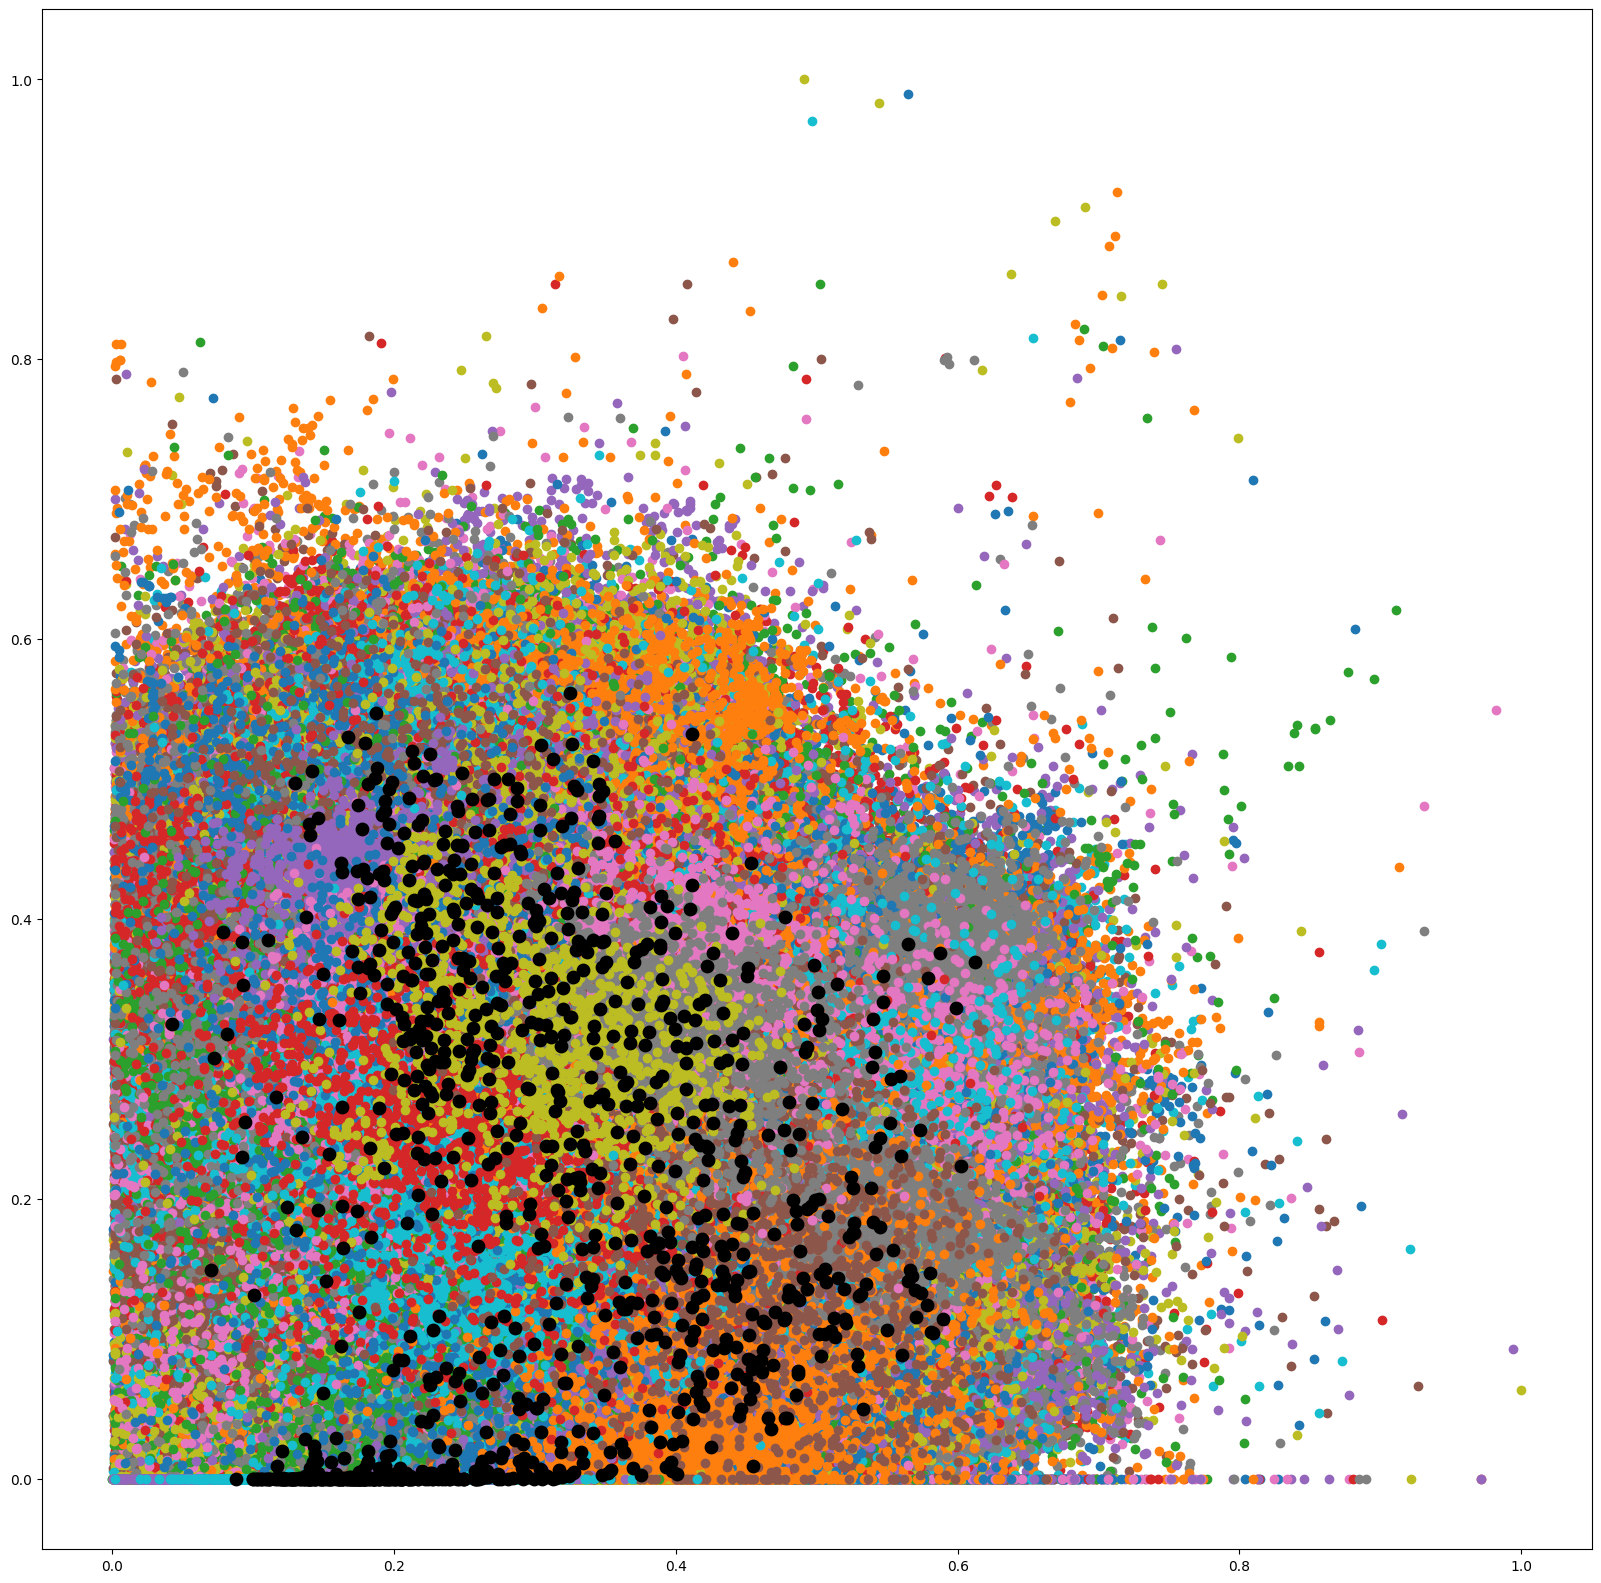

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

X_value = X.values
kmeans = KMeans(n_clusters = 1000, init = 'k-means++', max_iter = 100, n_init = 10, random_state = 0)
# kmeans = KMeans(n_clusters = 1000, random_state = 42)

# kmeans.fit(X)
X_normalized = normalize(X_value, axis=1)
label = kmeans.fit_predict(X_value)

#Getting the Centroids
centroids = kmeans.cluster_centers_
u_labels = np.unique(label)
 
# plotting the results:
plt.figure(figsize=(20, 20))

for i in u_labels:
    plt.scatter(X_value[label == i , 0] , X_value[label == i , 1] , label = i)
plt.scatter(centroids[:,0] , centroids[:,1] , s = 80, color = 'k')
# plt.legend()
plt.show()

2024-11-03 01:31:39.304722
50  inertion:  99975.24576696556
2024-11-03 01:31:59.457259
100  inertion:  87352.33914058322
2024-11-03 01:33:02.433653
150  inertion:  81154.85625961267
2024-11-03 01:34:36.390461
200  inertion:  77091.79707899348
2024-11-03 01:36:34.781868
250  inertion:  74221.12178466495
2024-11-03 01:38:47.039168
300  inertion:  71975.09179206721
2024-11-03 01:41:17.708954
350  inertion:  70143.14696403596
2024-11-03 01:44:10.900042
400  inertion:  68550.68961038378
2024-11-03 01:48:01.624026
450  inertion:  67267.61733874306
2024-11-03 01:52:18.954100
500  inertion:  66111.283991146
2024-11-03 01:56:50.928854
550  inertion:  65101.2587512357
2024-11-03 02:01:51.479026
600  inertion:  64209.99498255641
2024-11-03 02:07:19.072988
650  inertion:  63367.7231591967
2024-11-03 02:13:14.315016
700  inertion:  62618.58999002135
2024-11-03 02:19:35.548261
750  inertion:  61936.74335544066
2024-11-03 02:26:25.295503
800  inertion:  61316.055874282596
2024-11-03 02:33:40.821160
8

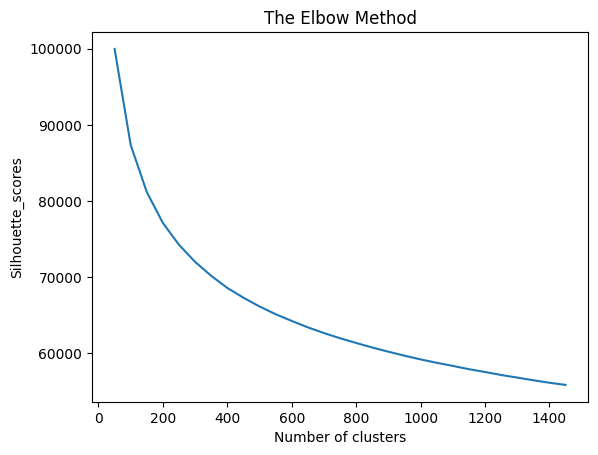

In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import datetime

inertia_list = []
range_list = range(50, 1500, 50)
X_value = X.values
X_normalized = normalize(X_value, axis=1)

for i in range_list:
    print(datetime.datetime.now())
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(X_normalized)
    print(i, " inertion: ", kmeans.inertia_)
    inertia_list.append(kmeans.inertia_)

plt.plot(range_list, inertia_list)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_scores')
plt.show()

# **------- Extras -------** 

In [6]:
import glob
import shutil
import os

# src_dir = "/media/osero/SamsungSSD/CMPE_SSD/frame-hand_left-c256/0001/User_2_001"
src_dir = "/media/osero/SamsungSSD/CMPE_SSD/frame-hand_left-c256"
dst_dir = "/media/osero/SamsungSSD/CMPE_SSD/labeled_frames"
def copy_image(label_number):
    save_folder = os.path.join(dst_dir, str(label_number).zfill(4))
    if os.path.exists(save_folder):
        shutil.rmtree(save_folder)
    os.makedirs(save_folder)

    data_list = df[(df['lunate_bone_x'] != 0)][label == label_number]
    for processed_data in data_list.iterrows():
        folder_path = os.path.join(src_dir, str(processed_data[1]['ClassNumber']).zfill(4))
        folder_path = os.path.join(folder_path, str(processed_data[1]['User']).zfill(4))
        folder_path = os.path.join(folder_path, str(processed_data[1]['Frame']+1).zfill(3))
        jpg_file_path = folder_path + '.jpg'
        save_full_path = save_folder + '/' + str(processed_data[1]['ClassNumber']) + '_' + processed_data[1]['User'] + '_' + str(processed_data[1]['Frame']) + '.jpg'
        # print('jpg_file_path: ', jpg_file_path)

        shutil.copy(jpg_file_path, save_full_path)

for i in range (1,20):
    copy_image(i)